# WORK 2 : WAVEFORM DETECTION IN NON-STATIONARY NOISE

### Objective

Compare the performance of rolling variance and GARCH(1,1)-based variance estimation for detecting a toy inspiral chirp signal in simulated non-stationary noise.

### Procedure

1. Generate a toy inspiral chirp waveform.
2. Generate non-stationary Gaussian noise with a time-varying standard deviation.
3. Estimate the noise variance using:
   - Rolling variance
   - GARCH(1,1) conditional variance
4. Compute the likelihood ratio for the signal-plus-noise and noise-only cases.
5. Repeat the experiment using Monte Carlo simulations.
6. Generate ROC curves and compare the detection performance of the two methods.

### Outputs

- ROC curve using rolling variance.
- ROC curve using GARCH(1,1) variance estimation.
- Comparison of the detection performance.

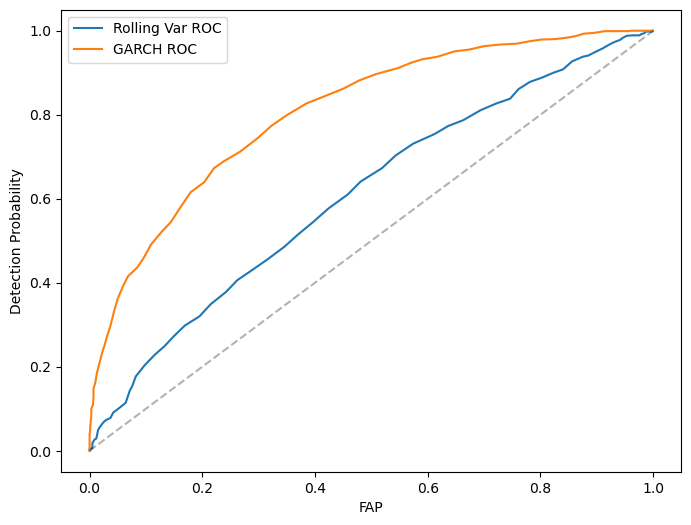

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from arch import arch_model

# -----------------------------
# 1. Setup & Chirp Model
# -----------------------------
def generate_chirp(t, chirp_rate, t_c):
    h = np.zeros_like(t)
    valid = (t < t_c) & (t > (t_c - 2.0))
    if not np.any(valid): return h
    tau = t_c - t[valid]
    phase = -2.0 * chirp_rate * (tau + 1e-5)**(-0.25)
    amplitude = 1e-22 * (chirp_rate / (tau + 0.1))**0.5
    h[valid] = amplitude * np.sin(phase)
    return h

def compute_log_likelihood(data, model, sigma_t):
    residual = data - model
    # The variance is time-varying, so we compute based on the sigma_t vector
    return -0.5 * np.sum(np.log(2.0 * np.pi * sigma_t**2) + (residual**2) / (sigma_t**2))

N = 1000
t = np.linspace(0, 10, N)
params = (5.0, 8.0)
signal_template = generate_chirp(t, *params)

# --- SIGMA(T) FUNCTION ---
# sigma(t) = 1 + 15*t*sin^2(2*pi*t)
# We apply the 1e-22 scaling to match the signal amplitude level
sigma_t_true = 1e-22 * (1 + 15 * t * np.sin(2 * np.pi * t)**2)

num_trials = 1000
log_l_sig_rolling, log_l_noise_rolling = [], []
log_l_sig_garch, log_l_noise_garch = [], []

for i in range(num_trials):
    # Noise follows the deterministic sigma(t)
    noise = np.random.normal(0, 1, N) * sigma_t_true
    
    # 1. Rolling Variance (as a baseline)
    rolling_sigma = pd.Series(noise).rolling(window=50, center=True, min_periods=1).std().fillna(1e-22).values
    
    # 2. GARCH Conditional Sigma
    am = arch_model(noise * 1e21, vol='GARCH', p=1, q=1, dist='Normal')
    res = am.fit(disp='off')
    conditional_sigma = res.conditional_volatility * 1e-21
    
    # Likelihood Ratio Logic
    data_sig = signal_template + noise
    
    log_l_sig_rolling.append(compute_log_likelihood(data_sig, signal_template, rolling_sigma) - compute_log_likelihood(data_sig, 0, rolling_sigma))
    log_l_noise_rolling.append(compute_log_likelihood(noise, signal_template, rolling_sigma) - compute_log_likelihood(noise, 0, rolling_sigma))
    
    log_l_sig_garch.append(compute_log_likelihood(data_sig, signal_template, conditional_sigma) - compute_log_likelihood(data_sig, 0, conditional_sigma))
    log_l_noise_garch.append(compute_log_likelihood(noise, signal_template, conditional_sigma) - compute_log_likelihood(noise, 0, conditional_sigma))

# -----------------------------
# 4. ROC Curve Generation
# -----------------------------
def get_roc(sig_stats, noise_stats):
    thresholds = np.linspace(min(min(sig_stats), min(noise_stats)), max(max(sig_stats), max(noise_stats)), 100)
    pd_arr = [np.sum(sig_stats > T) / num_trials for T in thresholds]
    fap_arr = [np.sum(noise_stats > T) / num_trials for T in thresholds]
    return fap_arr, pd_arr

fap_r, pd_r = get_roc(log_l_sig_rolling, log_l_noise_rolling)
fap_g, pd_g = get_roc(log_l_sig_garch, log_l_noise_garch)

plt.figure(figsize=(8,6))
plt.plot(fap_r, pd_r, label='Rolling Var ROC')
plt.plot(fap_g, pd_g, label='GARCH ROC')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("FAP"); plt.ylabel("Detection Probability"); plt.legend(); plt.show()